<a href="https://colab.research.google.com/github/tanishataranoon/MY_ML_project/blob/main/Comparison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Toxic Comment Classification:
# A Comparative Study of ML, DL, and Transformer Models

# Course: CSE 414 - ML & DL Lab


# 1. Install & import

In [ ]:
!pip install pandas numpy matplotlib seaborn scikit-learn nltk wordcloud transformers torch --quiet

In [ ]:
# Core
import numpy as np
import pandas as pd
import re
import time
import pickle

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# NLP
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

# ML
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import *

# DL
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import *

# Transformer
import torch
from transformers import *

sns.set_theme(style='whitegrid')

# 2. Dataset Loading

from https://huggingface.co/datasets/thesofakillers/jigsaw-toxic-comment-classification-challenge?library=datasets


## 2.1 Load dataset


In [ ]:
from datasets import load_dataset

df = load_dataset("thesofakillers/jigsaw-toxic-comment-classification-challenge")

## 2.2 Basic inspection

In [ ]:
df

DatasetDict({
    train: Dataset({
        features: ['id', 'comment_text', 'toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate'],
        num_rows: 159571
    })
    test: Dataset({
        features: ['id', 'comment_text', 'toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate'],
        num_rows: 306328
    })
})

In [ ]:
train_df = df['train'].to_pandas()
test_df = df['test'].to_pandas()
print(train_df.shape)
print(test_df.shape)

(159571, 8)
(306328, 8)


## 2.3 Label setup & Toxic distribution

In [ ]:
print('Columns: ', train_df.columns.tolist())

Columns:  ['id', 'comment_text', 'toxic', 'severe_toxic', 'obscene', 'threat', 'insult', 'identity_hate']


In [ ]:
print('\nData Types: \n', train_df.dtypes)


Data Types: 
 id               object
comment_text     object
toxic             int64
severe_toxic      int64
obscene           int64
threat            int64
insult            int64
identity_hate     int64
dtype: object


In [ ]:
label_cols = ["toxic", "severe_toxic", "obscene", "threat", "insult", "identity_hate"]
train_df['any_toxic'] = train_df[label_cols].max(axis=1)


print(f'Total comments    : {len(train_df):,}')
print(f'Toxic comments    : {train_df["any_toxic"].sum():,} ({train_df["any_toxic"].mean()*100:.1f}%)')
print(f'Non-toxic comments: {(train_df["any_toxic"]==0).sum():,} ({(train_df["any_toxic"]==0).mean()*100:.1f}%)')

Total comments    : 159,571
Toxic comments    : 16,225 (10.2%)
Non-toxic comments: 143,346 (89.8%)


# 3 . Exploratory Data Analysis (EDA)


## 3.1 Label distribution

In [ ]:
label_counts = train_df[label_cols].sum().sort_values(ascending=False)
print(label_counts)

toxic            15294
obscene           8449
insult            7877
severe_toxic      1595
identity_hate     1405
threat             478
dtype: int64


In [ ]:
co_matrix = train_df[label_cols].T.dot(train_df[label_cols])
co_matrix

,toxic,severe_toxic,obscene,threat,insult,identity_hate
toxic,15294,1595,7926,449,7344,1302
severe_toxic,1595,1595,1517,112,1371,313
obscene,7926,1517,8449,301,6155,1032
threat,449,112,301,478,307,98
insult,7344,1371,6155,307,7877,1160
identity_hate,1302,313,1032,98,1160,1405


## 3.2 Toxic vs non-toxic

Bar Chart of Number of Comments per Toxicity Label
A pie chart for non-toxic vs toxic

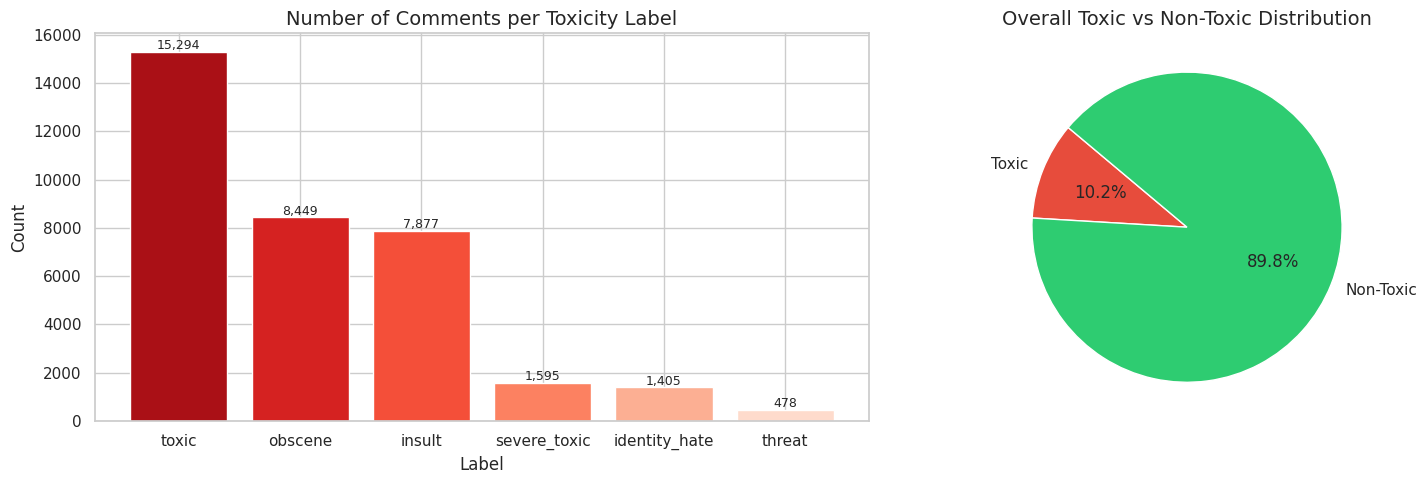

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].bar(label_counts.index, label_counts.values, color=sns.color_palette('Reds_r', len(label_cols)))
axes[0].set_title('Number of Comments per Toxicity Label', fontsize=14)
axes[0].set_xlabel('Label')
axes[0].set_ylabel('Count')
for i, v in enumerate(label_counts.values):
    axes[0].text(i, v + 100, f'{v:,}', ha='center', fontsize=9)

axes[1].pie(
    [train_df['any_toxic'].sum(), (train_df['any_toxic']==0).sum()],
    labels=['Toxic', 'Non-Toxic'],
    autopct='%1.1f%%',
    colors=['#e74c3c', '#2ecc71'],
    startangle=140
)
axes[1].set_title('Overall Toxic vs Non-Toxic Distribution', fontsize=14)

plt.tight_layout()
plt.savefig('label_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 3.3 Co-occurrence heatmap

Multi-label Co-occurrence Heatmap a comment can belong to multiple categories at the same time

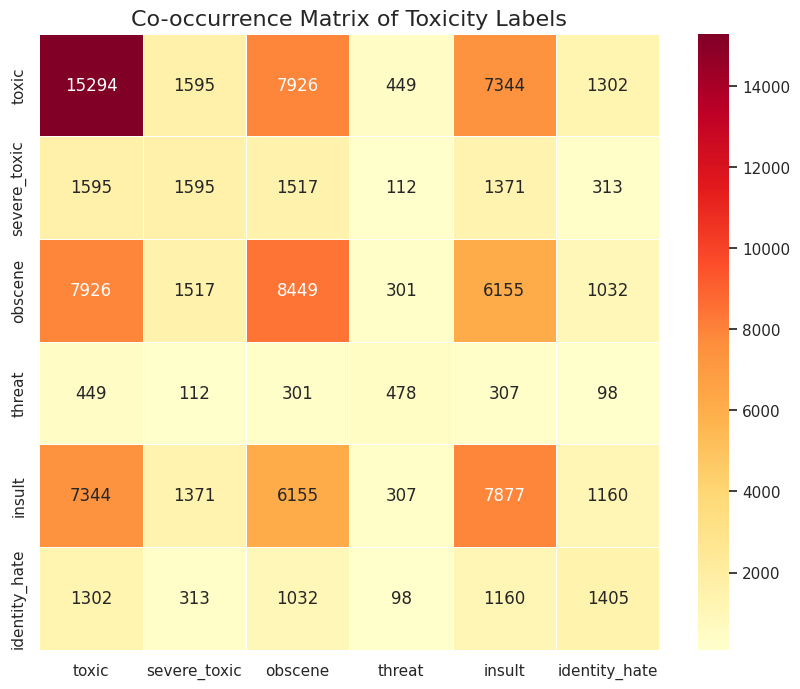

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(co_matrix, annot=True, fmt='d', cmap='YlOrRd', linewidths=0.5)
plt.title('Co-occurrence Matrix of Toxicity Labels', fontsize=16)
plt.savefig('co_occurrence_matrix.png', dpi=150, bbox_inches='tight')
plt.show()


## 3.4 Word clouds

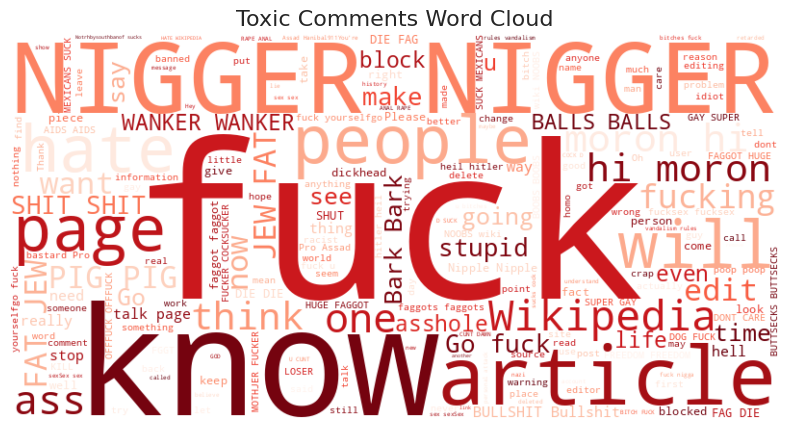

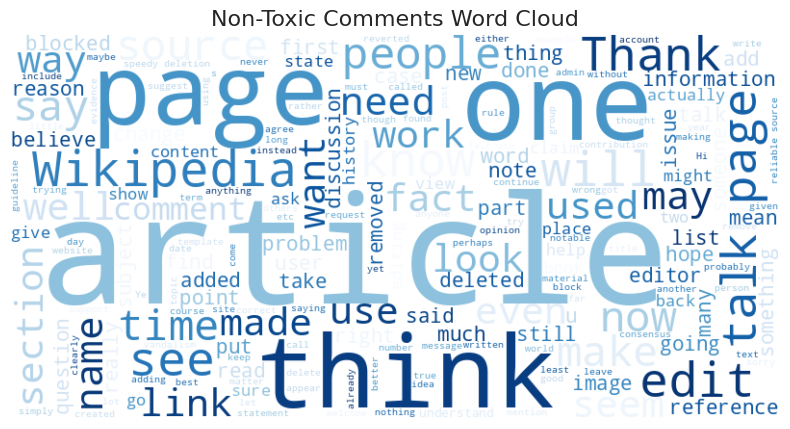

In [ ]:
def generate_wordcloud(text_data, title, colormap='Reds'):
  text=' '.join(text_data)
  wordcloud = WordCloud(
      width=800,
      height=400,
      background_color='white',
      colormap=colormap,
      max_words=200,
    ).generate(text)
  plt.figure(figsize=(10, 5))
  plt.imshow(wordcloud, interpolation='bilinear')
  plt.title(title, fontsize=16)
  plt.axis('off')
  plt.show()

generate_wordcloud(train_df[train_df['any_toxic'] == 1]['comment_text'], 'Toxic Comments Word Cloud','Reds')
generate_wordcloud(train_df[train_df['any_toxic'] == 0]['comment_text'], 'Non-Toxic Comments Word Cloud', 'Blues')

## 3.5 Top n-grams

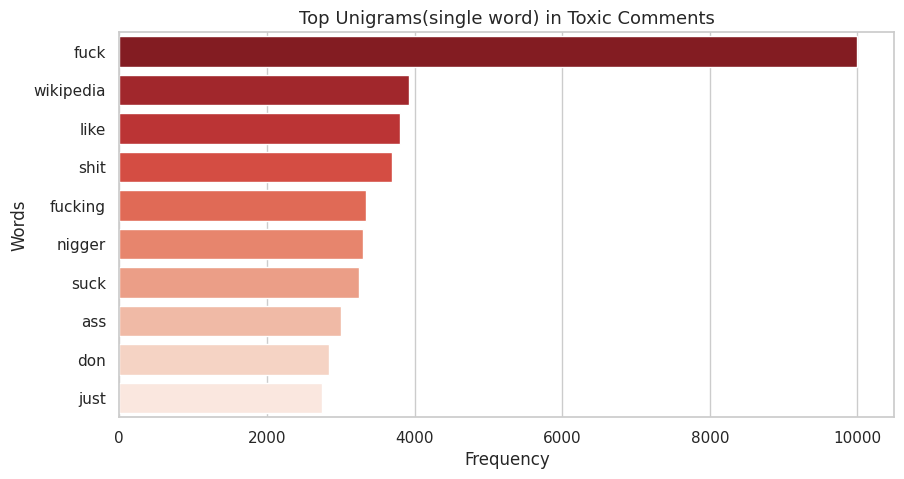

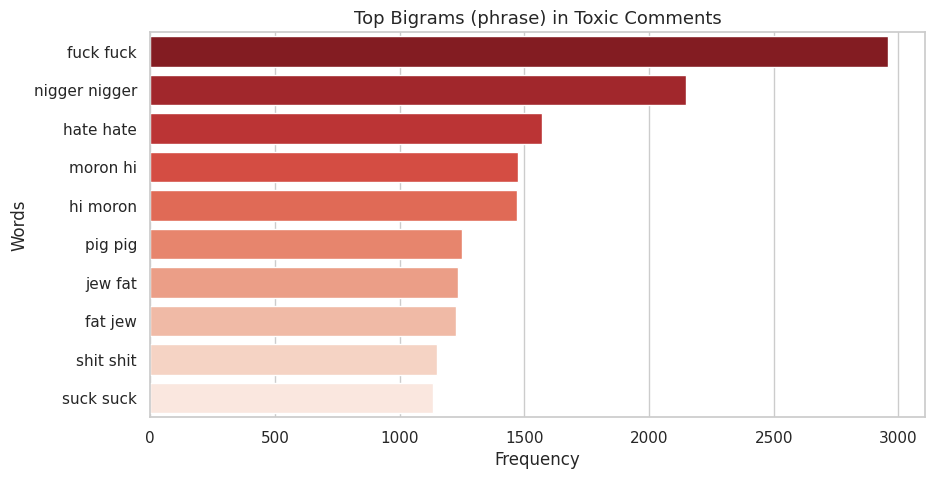

In [ ]:
from numpy import vecdot
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt
import seaborn as sns

def get_top_ngrams (corpus, title, ngram_range=(1,1), top_n=10):
  vec = CountVectorizer(ngram_range=ngram_range, stop_words='english', max_features=1000).fit(corpus)
  bag_of_words = vec.transform(corpus)
  sum_words = bag_of_words.sum(axis=0)
  words_freq = [(word, sum_words[0, idx]) for word, idx in vec.vocabulary_.items()]
  words_freq = sorted(words_freq, key=lambda x: x[1], reverse=True)

  top_n_ngrams = words_freq[:top_n]
  words = [word for word, freq in top_n_ngrams]
  freq = [freq for word, freq in top_n_ngrams]

  plt.figure(figsize=(10, 5))
  sns.barplot(
    x=list(freq),
    y=list(words),
    hue=list(words),
    palette='Reds_r',
    legend=False
  )
  plt.title(title, fontsize=13)
  plt.xlabel('Frequency', fontsize=12)
  plt.ylabel('Words', fontsize=12)
  plt.show()

toxic_comments = train_df[train_df['any_toxic'] == 1]['comment_text'].dropna()

get_top_ngrams(toxic_comments, 'Top Unigrams(single word) in Toxic Comments', ngram_range=(1,1), top_n=10)
get_top_ngrams(toxic_comments, 'Top Bigrams (phrase) in Toxic Comments', ngram_range=(2,2), top_n=10)

# 4. Preprocessing

## 4.1 Basic preprocessing



1.  Lower case



In [ ]:
def to_lower(text):
    return text.lower()




2. URL remove



In [ ]:
def remove_urls(text):
    import re
    return re.sub(r"http\S+|www\S+", "", text)

3. Mentions remove




In [ ]:
def remove_mentions(text):
    import re
    return re.sub(r"@\w+", "", text)

4. Remove Punctuation

In [ ]:
def remove_punctuation(text):
    import re
    return re.sub(r"[^a-zA-Z\s]", "", text)

5. Remove extra space

In [ ]:
def remove_extra_spaces(text):
    import re
    return re.sub(r"\s+", " ", text).strip()

## 4.2 Advance Preprocessing

1. Emoji to text

In [ ]:
!pip install emoji
import emoji

def emoji_to_text(text):
  return emoji.demojize(text, delimiters=(" ", " "))

2. Convert to full forms

In [ ]:
def expand_contractions(text):
    contractions = {
        "ain't": "is not",
        "aren't": "are not",
        "can't": "cannot",
        "can't've": "cannot have",
        "'cause": "because",
        "don't": "do not",
        "you're": "you are",
        "it's": "it is",
        "i'm": "i am",
        "won't": "will not"
    }

    for k, v in contractions.items():
        text = text.replace(k, v)

    return text

3. Normalize repetitions\
stuuuuupid → stupid

In [ ]:
def normalize_repeated_chars(text):
    return re.sub(r"(.)\1{2,}", r"\1\1", text)

4.Bad Word Normalization \
b!tch = bitch

In [ ]:
def normalize_obscene(text):
    text = text.replace("b!tch", "bitch")
    text = text.replace("f*ck", "fuck")
    text = text.replace("a$$", "ass")
    return text

5. Tokenization

In [ ]:
def tokenize_text(text):
    return word_tokenize(text)

6. Stopwords

In [ ]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [ ]:
stop_words = set(stopwords.words('english'))

def remove_stopwords(tokens):
    return [t for t in tokens if t not in stop_words]

7. Lemmatize

In [ ]:
lemmatizer = WordNetLemmatizer()

def lemmatize_tokens(tokens):
    return [lemmatizer.lemmatize(t) for t in tokens]

## 4.3 Final pipelines



1.   Basic Preprocess Function



In [ ]:
def basic_preprocess(text):
    text = to_lower(text)
    text = remove_urls(text)
    text = remove_mentions(text)
    text = remove_punctuation(text)
    text = remove_extra_spaces(text)
    return text



2.  Advanced Preprocess Function



In [ ]:
def advanced_preprocess(text, remove_sw=True, lemmatize=True):
    text = emoji_to_text(text)
    text = expand_contractions(text)
    text = normalize_obscene(text)
    text = normalize_repeated_chars(text)

    text = to_lower(text)
    text = remove_urls(text)
    text = remove_mentions(text)
    text = remove_punctuation(text)
    text = remove_extra_spaces(text)

    tokens = tokenize_text(text)

    if remove_sw:
        tokens = remove_stopwords(tokens)

    if lemmatize:
        tokens = lemmatize_tokens(tokens)

    return " ".join(tokens)

# 5. Apply Preprocessing



## 1. Applying Basic Preprocess Function






In [ ]:
train_df["raw"] = train_df["comment_text"]
train_df["basic_clean"] = train_df["raw"].apply(basic_preprocess)

Comparison Of Raw and Basic Clean by Basic Preprocessing

In [ ]:
pd.set_option('display.max_colwidth', None)
train_df[["raw", "basic_clean"]].sample(5)

,raw,basic_clean
119105,"Geez, are you forgetful! We've already discussed why Marx was not an anarchist, i.e. he wanted to use a State to mold his 'socialist man.' Ergo, he is a statist - the opposite of an anarchist. I know a guy who says that, when he gets old and his teeth fall out, he'll quit eating meat. Would you call him a vegetarian?",geez are you forgetful weve already discussed why marx was not an anarchist ie he wanted to use a state to mold his socialist man ergo he is a statist the opposite of an anarchist i know a guy who says that when he gets old and his teeth fall out hell quit eating meat would you call him a vegetarian
131631,"Carioca RFA \n\nThanks for your support on my request for adminship.\n\nThe final outcome was (31/4/1), so I am now an administrator. If you have any comments or concerns on my actions as an administrator, please let me know. Thank you!",carioca rfa thanks for your support on my request for adminship the final outcome was so i am now an administrator if you have any comments or concerns on my actions as an administrator please let me know thank you
125326,"""\n\n Birthday \n\nNo worries, It's what I do ;)Enjoy ur day|talk|e """,birthday no worries its what i do enjoy ur daytalke
111256,"Pseudoscience category? \n\nI'm assuming that this article is in the pseudoscience category because of its association with creationism. However, there are modern, scientifically-accepted variants of catastrophism that have nothing to do with creationism — and they're even mentioned in the article! I think the connection to pseudoscience needs to be clarified, or the article made more general and less creationism-specific and the category tag removed entirely.",pseudoscience category im assuming that this article is in the pseudoscience category because of its association with creationism however there are modern scientificallyaccepted variants of catastrophism that have nothing to do with creationism and theyre even mentioned in the article i think the connection to pseudoscience needs to be clarified or the article made more general and less creationismspecific and the category tag removed entirely
83590,"(and if such phrase exists, it would be provided by search engine even if mentioned page is not available as a whole)",and if such phrase exists it would be provided by search engine even if mentioned page is not available as a whole


## 2. Applying Advanced Preprocess Function

In [ ]:
nltk.download('wordnet')
nltk.download('punkt_tab')


[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [ ]:
train_df["advanced_clean"] = train_df["raw"].apply(advanced_preprocess)

Comparison of Raw and Advanced Clean by Advanced Preprocessing

In [ ]:
pd.set_option('display.max_colwidth', None)
train_df[["raw","advanced_clean"]].sample(5)

,raw,advanced_clean
80988,"""\n\nI have struck out my comment on the WP:RfC page, as you are quite correct in saying that I have no evidence for my """"suspicion"""", although I don't agree with your comment that you had """"already explained that you have been browsing WP for some time"""" - I can't see where you explained this previously. (talk) """,struck comment wprfc page quite correct saying evidence suspicion although agree comment already explained browsing wp time see explained previously talk
141463,please do not reinsert,please reinsert
44537,"""\n\nwell its not """"Vanderlism"""" as you state it. You still should allow the other part of my edit that you keep reverting because you hate the genre so much. 75.139.103.133 """,well vanderlism state still allow part edit keep reverting hate genre much
10601,"""\nFor the record, here is the news blurb that made en.wiki main page news: """"Amid an outbreak of tornadoes and derechos in central and eastern North America, a tornado hits a Boy Scout camp in Iowa, killing four.""""... — • Talk • """,record news blurb made enwiki main page news amid outbreak tornado derechos central eastern north america tornado hit boy scout camp iowa killing four talk
149256,"cajuns, acadians\nCajuns, acadians, louisianans, they're so many different names for different americans of french descent because their culture is so rich and somewhat so different but so close at the same time. I'm an acadian but more importantly I'm a french american so I really don't see why there should be a difference. \n\nIf you say there should be two different list, it doesn't make sense. The people on the french-american list should be in one of wiki-invented list of cajuns or acadians. I understand there are some more recent french-americans who are only 1 or 2 generations-old americans but this distinction isn't made for italian-americans, german-americans. I'm surprised to see Albert Einstein a fairly recent immigrant in American history next to Katherine Heigl, a 10 to 12 generations american. \\\n\nThis is all race-based, biased because french-bashing don't stop at the bush government level.",cajun acadian cajun acadian louisianan theyre many different name different american french descent culture rich somewhat different close time im acadian importantly im french american really see difference say two different list doesnt make sense people frenchamerican list one wikiinvented list cajun acadian understand recent frenchamericans generationsold american distinction isnt made italianamericans germanamericans im surprised see albert einstein fairly recent immigrant american history next katherine heigl generation american racebased biased frenchbashing stop bush government level


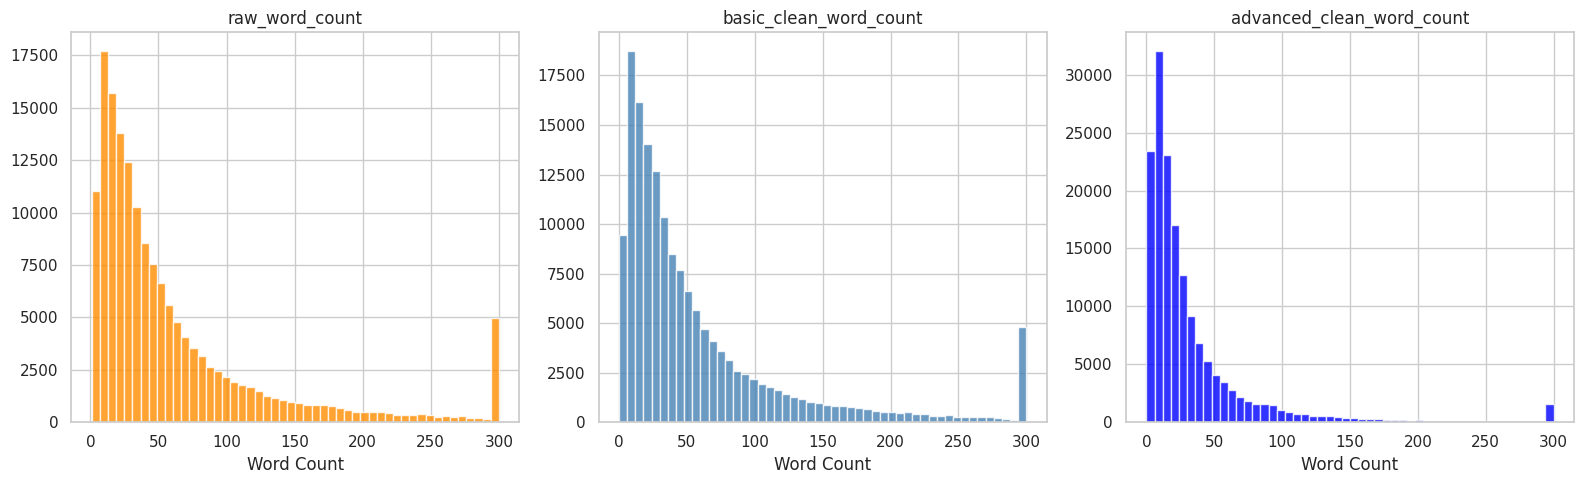

In [ ]:
train_df['raw_word_count'] =train_df['comment_text'].str.split().str.len()
train_df['basic_clean_word_count'] =train_df['basic_clean'].str.split().str.len()
train_df['advanced_clean_word_count'] =train_df['advanced_clean'].str.split().str.len()

fig, axes = plt.subplots(1, 3, figsize=(16,5))
axes[0].hist(train_df['raw_word_count'].clip(upper=300),bins=50,color="darkorange", edgecolor='white',alpha=0.8)
axes[0].set_title('raw_word_count' , fontsize=12)
axes[0].set_xlabel('Word Count')


axes[1].hist(train_df['basic_clean_word_count'].clip(upper=300),bins=50,color="steelblue", edgecolor='white',alpha=0.8)
axes[1].set_title('basic_clean_word_count' , fontsize=12)
axes[1].set_xlabel('Word Count')


axes[2].hist(train_df['advanced_clean_word_count'].clip(upper=300),bins=50,color="blue", edgecolor='white',alpha=0.8)
axes[2].set_title('advanced_clean_word_count' , fontsize=12)
axes[2].set_xlabel('Word Count')

plt.tight_layout()
plt.savefig('word_count_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
print('Raw text stats:')    ; print(train_df['raw_word_count'].describe().round(1))
print('\n basic Cleaned text stats:'); print(train_df['basic_clean_word_count'].describe().round(1))
print('\n advance Cleaned text stats:'); print(train_df['advanced_clean_word_count'].describe().round(1))


Raw text stats:
count    159571.0
mean         67.3
std          99.2
min           1.0
25%          17.0
50%          36.0
75%          75.0
max        1411.0
Name: raw_word_count, dtype: float64

 basic Cleaned text stats:
count    159571.0
mean         65.4
std          97.3
min           0.0
25%          16.0
50%          35.0
75%          73.0
max        1403.0
Name: basic_clean_word_count, dtype: float64

 advance Cleaned text stats:
count    159571.0
mean         34.0
std          52.5
min           0.0
25%           8.0
50%          18.0
75%          37.0
max        1250.0
Name: advanced_clean_word_count, dtype: float64


# 6. Train/Validation/Test Split

In [ ]:
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)
x = train_df[['raw','basic_clean','advanced_clean']]
y = train_df[label_counts.index]

X_train, X_temp, y_train, y_temp = train_test_split(
    x, y, test_size=0.2, random_state=RANDOM_SEED, stratify=train_df['any_toxic']
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=RANDOM_SEED,
    stratify=y_temp.max(axis=1)
)

print(f'Train : {len(X_train):,}  |  Val : {len(X_val):,}  |  Test : {len(X_test):,}')


Train : 127,656  |  Val : 15,957  |  Test : 15,958


# 7. Feature Extraction

## 7.1 TF-IDF Features

(for LR and SVM)
use advanced_clean

In [ ]:
tfidf = TfidfVectorizer(
    max_features=50000 ,
    ngram_range=(1,2),
    sublinear_tf=True,
    min_df =3
)
X_train_tfidf = tfidf.fit_transform(X_train['advanced_clean'])
X_val_tfidf = tfidf.transform(X_val['advanced_clean'])
X_test_tfidf = tfidf.transform(X_test['advanced_clean'])

In [ ]:
print('TD_IFD shape train', X_train_tfidf.shape)
print('TD_IFD shape val', X_val_tfidf.shape)
print('TD_IFD shape test', X_test_tfidf.shape)

TD_IFD shape train (127656, 50000)
TD_IFD shape val (15957, 50000)
TD_IFD shape test (15958, 50000)


## 7.2 LSTM Tokenization

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [134]:
Vocab_size =10000
max_len= 100

lstm_tok = Tokenizer(num_words=Vocab_size, oov_token='<OOV>')
lstm_tok.fit_on_texts(X_train['advanced_clean'])

def to_padded(texts):
  seqs = lstm_tok.texts_to_sequences(texts)
  return pad_sequences(seqs, maxlen=max_len, padding='post', truncating='post')
X_train_lstm = to_padded(X_train['advanced_clean'])
X_val_lstm = to_padded(X_val['advanced_clean'])
X_test_lstm = to_padded(X_test['advanced_clean'])

## 7.3 BERT Tokenization

In [ ]:
from transformers import (BertTokenizer, BertForSequenceClassification,
                          get_linear_schedule_with_warmup)

In [ ]:
Bert_tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
def bert_encode(texts, max_len=512):
   enc =bert_tokenizer(
       list(texts),
       max_length=max_len,
       truncation=True,
       padding = 'max_length',
       return_tensors='tf'
   )
   return enc['input_ids'], enc['attention_mask']

# 8 . Evaluation Utilities

## 1. evaluate()

In [ ]:
results ={}
def evaluate(model_name,y_true,y_pred, elapsed_train=None,elapsed_infer=None ):
  acc = accuracy_score(y_true, y_pred)
  prec = precision_score(y_true, y_pred, average='macro',zero_division=0)
  rec = recall_score(y_true, y_pred, average='macro',zero_division=0)
  f1 = f1_score(y_true, y_pred, average='macro',zero_division=0)

  results[model_name] = {
      'accuracy': round(acc,4),
      'precision': round(prec,4),
      'recall': round(rec,4),
      'f1 (macro)': round(f1,4),
      'train time (s)':round( elapsed_train,1) if elapsed_train else '-',
      'infer time (s)': round(elapsed_infer,1) if elapsed_infer else '-'
  }
  print(f'\n===== {model_name} =====')
  print(f'  accuracy : {acc:.4f}')
  print(f'  precision: {prec:.4f}')
  print(f'  recall   : {rec:.4f}')
  print(f'  f1 Macro : {f1:.4f}')
  if elapsed_train: print(f'  train time: {elapsed_train:.1f}s')
  return results[model_name]

## 2. confusion matrix

In [ ]:
def plot_confusion(model_name,y_true, y_pred, lables=label_cols):
   fig, axes = plt.subplots( 2,3, figsize=(15,8))
   for ax, col in zip(axes.flatten(), lables):
       cm = confusion_matrix(y_true[:, lables.index(col)],
                              y_pred[:, lables.index(col)])
       sns.heatmap(cm, annot=True, fmt='d', ax=ax,
                    cmap='Blues', cbar=False)
       ax.set_title(col, fontsize=11)
       ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
   plt.suptitle(f'Confusion Matrices — {model_name}', fontsize=14)
   plt.tight_layout()
   plt.savefig(f'cm_{model_name.replace(" ","_")}.png', dpi=150, bbox_inches='tight')
   plt.show()

print('Evaluation helpers ready.')

Evaluation helpers ready.


# 9. Traditional ML Models

## 9.1 Logistic Regression

Raw Text

In [ ]:
tfidf_raw = TfidfVectorizer(max_features=50000, ngram_range=(1,2),sublinear_tf=True, min_df=3)
X_train_tfidf_raw = tfidf_raw.fit_transform(X_train['raw'])
X_test_tfidf_raw = tfidf_raw.transform(X_test['raw'])

lr_raw = OneVsRestClassifier(LogisticRegression(max_iter=1000, C=1.0, random_state=RANDOM_SEED))
t0 = time.time()
lr_raw.fit(X_train_tfidf_raw, y_train)
with open('lr_raw_model.pkl', 'wb') as f:
    pickle.dump(lr_raw, f)
with open('tfidf_raw_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf_raw, f)

In [ ]:
with open('tfidf_raw_vectorizer.pkl', 'rb') as f:
    loaded_tfidf = pickle.load(f)
with open('lr_raw_model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)

In [ ]:
train_t = time.time() - t0
print(f'Train time: {train_t:.1f}s')
t0=time.time()
y_pred_raw = lr_raw.predict(X_test_tfidf_raw)
infer_t= time.time() - t0

Train time: 17.7s


Evaluate the model for raw data

In [ ]:
evaluate('TF-IDF + LR (raw)', y_test.values, y_pred_raw, train_t, infer_t)


===== TF-IDF + LR (raw) =====
  accuracy : 0.9204
  precision: 0.8366
  recall   : 0.3936
  f1 Macro : 0.5099
  train time: 17.7s


{'accuracy': 0.9204,
 'precision': 0.8366,
 'recall': 0.3936,
 'f1 (macro)': 0.5099,
 'train time (s)': 17.7,
 'infer time (s)': 0.0}

Confusion plot for the model for raw data

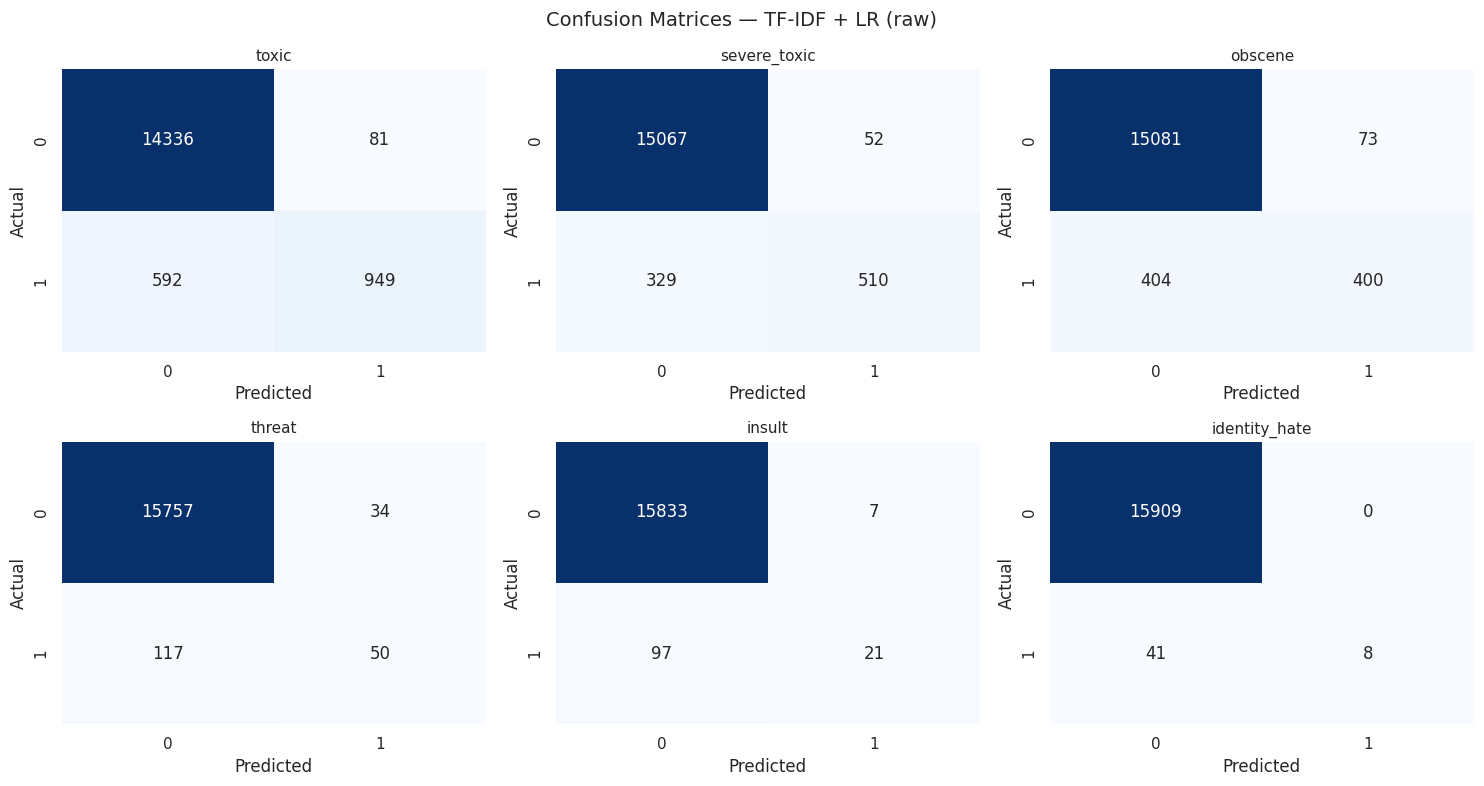

In [ ]:
plot_confusion('TF-IDF + LR (raw)', y_test.values, y_pred_raw, label_cols)

Advanced Clean

In [ ]:
tfidf_clean = TfidfVectorizer(max_features=50000, ngram_range=(1,2),sublinear_tf=True, min_df=3)
X_train_tfidf_clean = tfidf_clean.fit_transform(X_train['advanced_clean'])
X_test_tfidf_clean = tfidf_clean.transform(X_test['advanced_clean'])

lr_clean = OneVsRestClassifier(LogisticRegression(max_iter=1000, C=1.0, random_state=RANDOM_SEED))
t0 = time.time()
lr_clean.fit(X_train_tfidf_clean, y_train)
with open('lr_clean_model.pkl', 'wb') as f:
    pickle.dump(lr_clean, f)
with open('tfidf_clean_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf_clean, f)

In [ ]:
with open('tfidf_clean_vectorizer.pkl', 'rb') as f:
    loaded_tfidf = pickle.load(f)
with open('lr_clean_model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)

In [ ]:
train_t = time.time() - t0
print(f'Train time: {train_t:.1f}s')
t0=time.time()
y_pred_clean = lr_clean.predict(X_test_tfidf_clean)
infer_t= time.time() - t0

Train time: 9.5s


Evaluate the model for clean data

In [ ]:
evaluate('TF-IDF + LR (advanced)', y_test.values, y_pred_clean, train_t, infer_t)


===== TF-IDF + LR (advanced) =====
  accuracy : 0.9189
  precision: 0.7585
  recall   : 0.3845
  f1 Macro : 0.4852
  train time: 9.5s


{'accuracy': 0.9189,
 'precision': 0.7585,
 'recall': 0.3845,
 'f1 (macro)': 0.4852,
 'train time (s)': 9.5,
 'infer time (s)': 0.0}

Confusion plot for the model for clean data

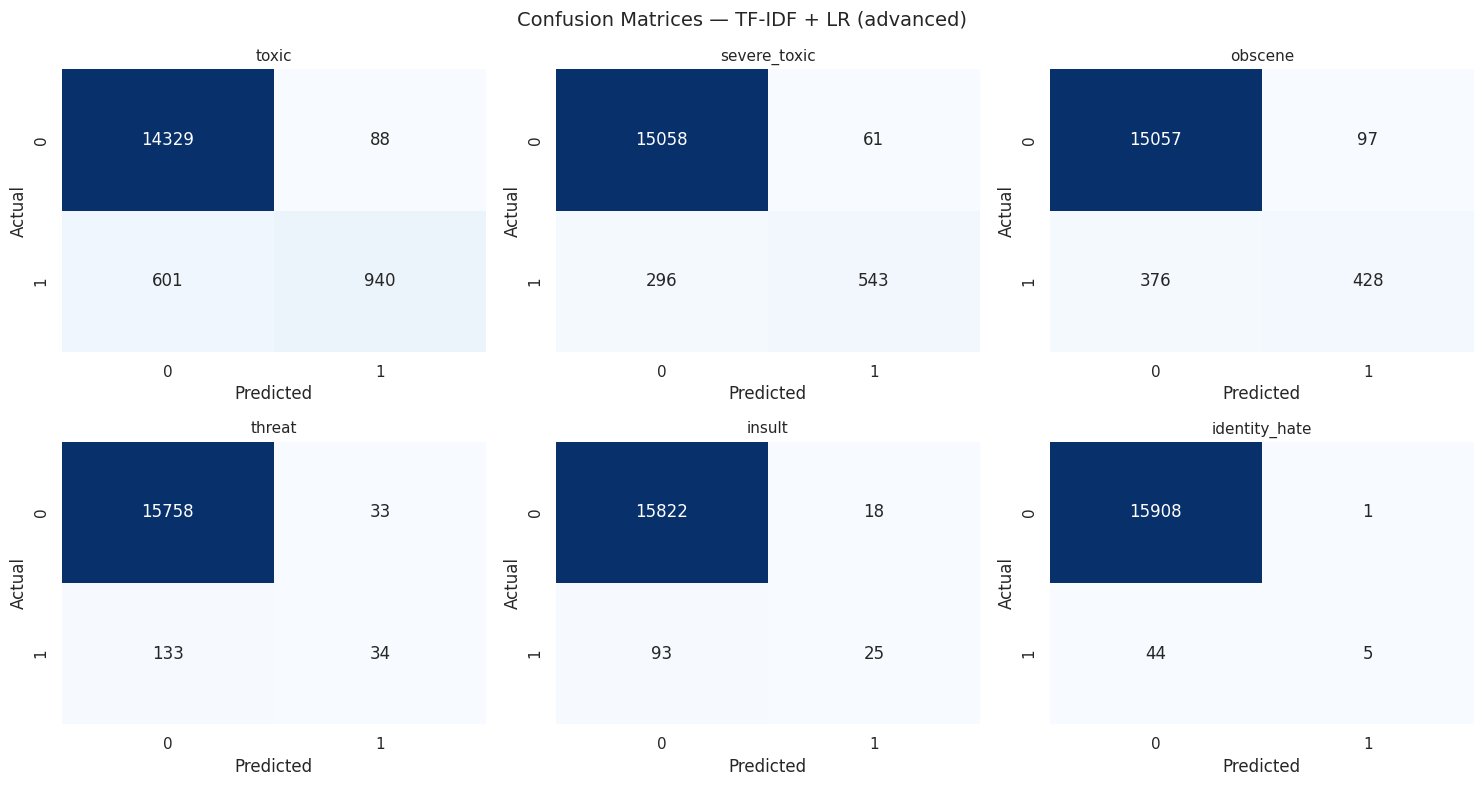

In [ ]:
plot_confusion('TF-IDF + LR (advanced)', y_test.values, y_pred_clean, label_cols)

## 9.2 SVM

Raw Text

In [ ]:
svm_raw = OneVsRestClassifier(LinearSVC(max_iter=2000, C=1.0, random_state=RANDOM_SEED))

t0= time.time()
svm_raw.fit(X_train_tfidf_raw, y_train)
with open('svm_raw_model.pkl', 'wb') as f:
    pickle.dump(svm_raw, f)

In [ ]:
with open('svm_raw_model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)

In [ ]:
train_t = time.time() - t0
print(f'Train time: {train_t:.1f}s')
t0=time.time()
y_pred_svm_raw = svm_raw.predict(X_test_tfidf_raw)
infer_t= time.time() - t0

Train time: 11.4s


Evaluate the model for raw data

In [ ]:
evaluate('TF-IDF + SVM (raw)', y_test.values, y_pred_svm_raw, train_t, infer_t)


===== TF-IDF + SVM (raw) =====
  accuracy : 0.9209
  precision: 0.7476
  recall   : 0.5065
  f1 Macro : 0.5944
  train time: 11.4s


{'accuracy': 0.9209,
 'precision': 0.7476,
 'recall': 0.5065,
 'f1 (macro)': 0.5944,
 'train time (s)': 11.4,
 'infer time (s)': 0.0}

Confusion plot for the model for raw data

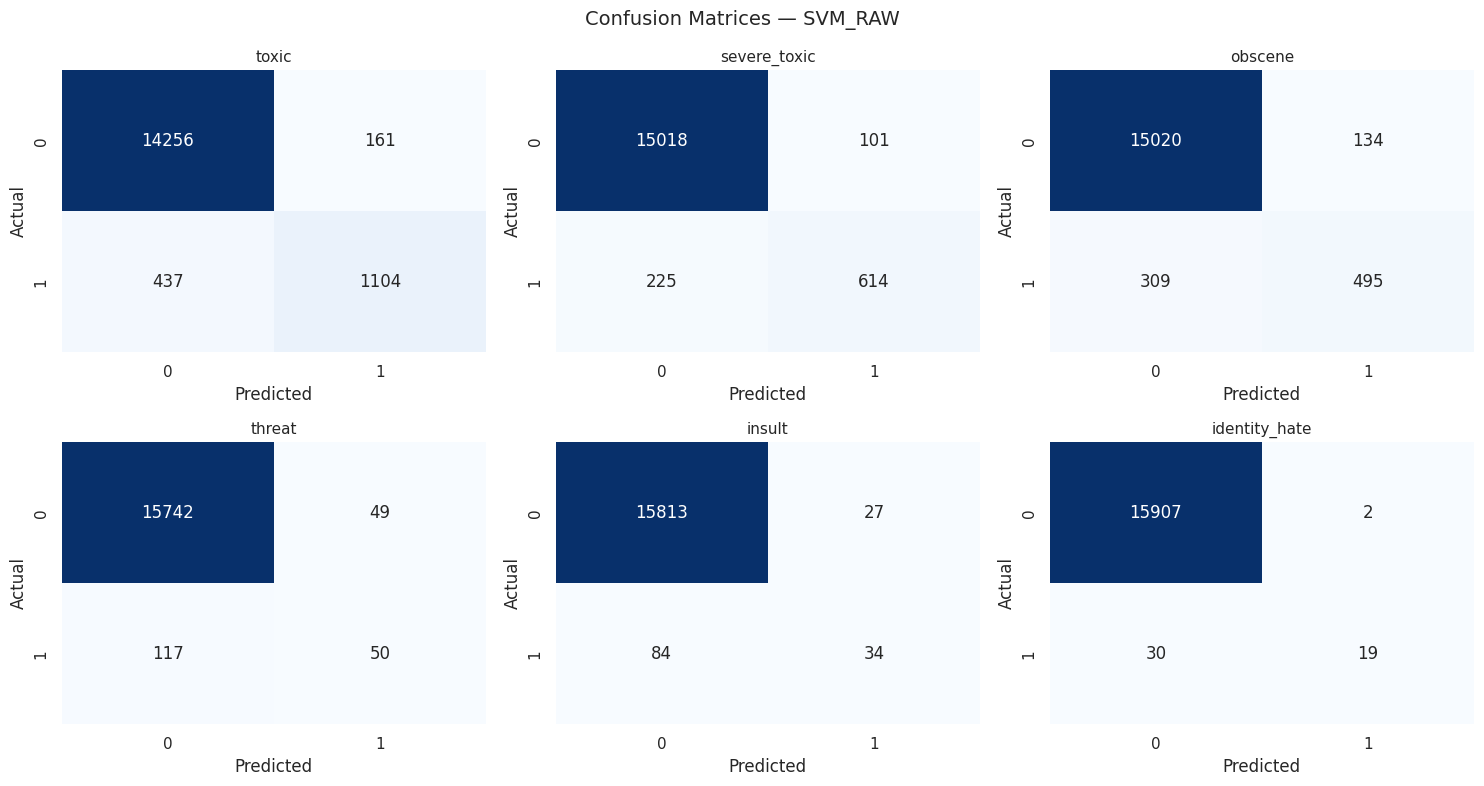

In [ ]:
plot_confusion('SVM_RAW',y_test.values,y_pred_svm_raw,label_cols)

Advanced Clean

In [ ]:
svm_clean= OneVsRestClassifier(LinearSVC(max_iter=2000, C=1.0, random_state=RANDOM_SEED))

t0= time.time()
svm_clean.fit(X_train_tfidf_clean, y_train)
with open('svm_clean_model.pkl', 'wb') as f:
    pickle.dump(svm_clean, f)

In [ ]:
with open('svm_clean_model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)

In [ ]:
train_t = time.time() - t0
print(f'Train time: {train_t:.1f}s')

t0=time.time()
y_pred_svm_clean = svm_clean.predict(X_test_tfidf_clean)
infer_t= time.time() - t0

Train time: 6.1s



Evaluate the model for clean data

In [ ]:
evaluate('TF-IDF + SVM (advanced)', y_test.values, y_pred_svm_clean, train_t, infer_t)


===== TF-IDF + SVM (advanced) =====
  accuracy : 0.9187
  precision: 0.7193
  recall   : 0.4957
  f1 Macro : 0.5780
  train time: 6.1s


{'accuracy': 0.9187,
 'precision': 0.7193,
 'recall': 0.4957,
 'f1 (macro)': 0.578,
 'train time (s)': 6.1,
 'infer time (s)': 0.0}

Confusion plot for the model for clean data

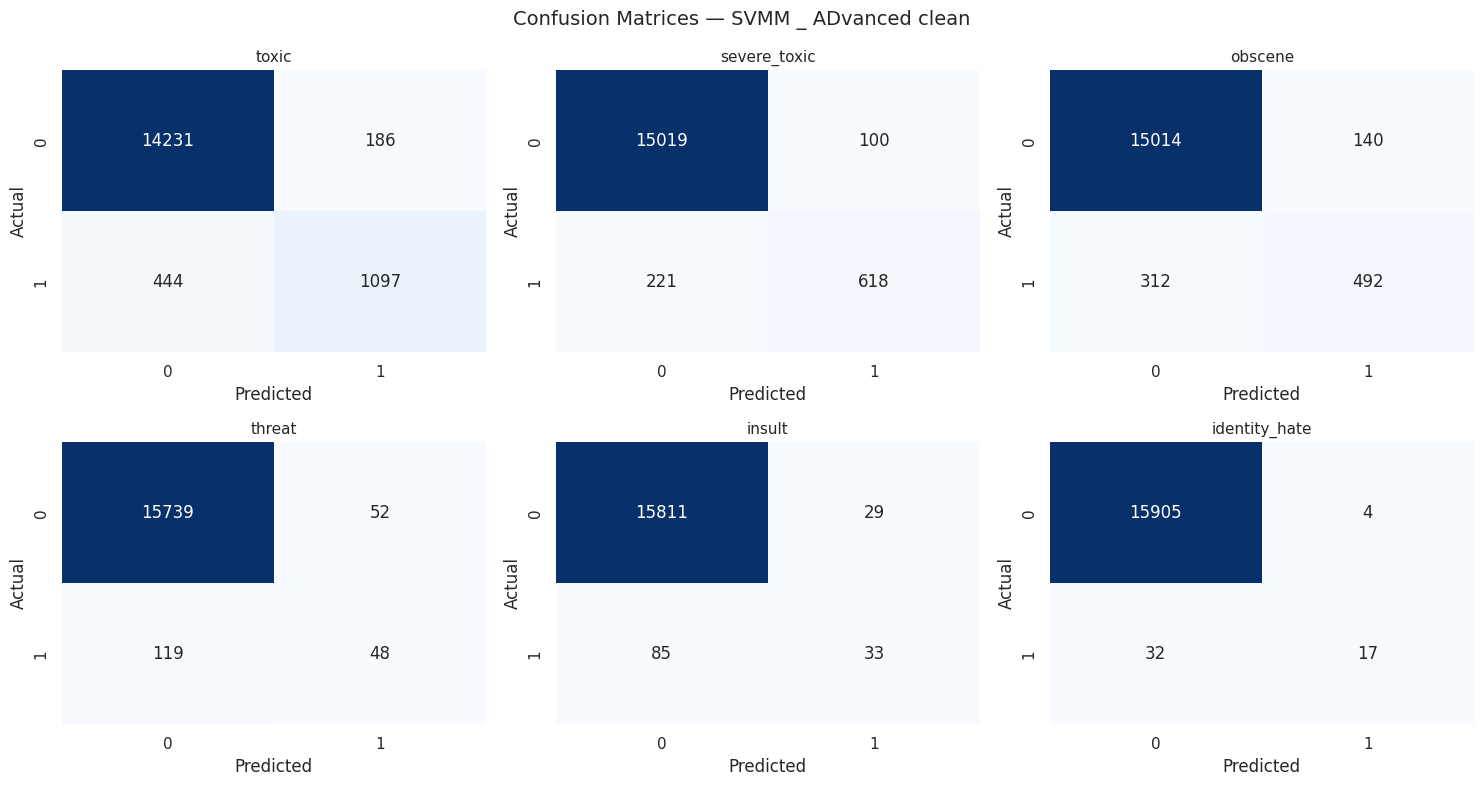

In [ ]:
plot_confusion("SVMM _ ADvanced clean", y_test.values, y_pred_svm_clean, label_cols)

# 10. Deep Learning Model

## 10.1 BiLSTM — Basic Clean

Building the model

In [135]:
EMBED_DIM = 128
NUM_LABELS = len(label_cols)

def build_bilstm(Vocab_size, max_len, num_labels):
    inp  = Input(shape=(max_len,))
    x    = Embedding(Vocab_size, EMBED_DIM)(inp)
    x    = Bidirectional(LSTM(64, return_sequences=True, dropout=0.2))(x)
    x    = GlobalMaxPooling1D()(x)
    x    = Dense(128, activation='relu')(x)
    x    = Dropout(0.3)(x)
    out  = Dense(num_labels, activation='sigmoid')(x)
    model = Model(inp, out)
    model.compile(optimizer='adam',
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model
lstm_model = build_bilstm(Vocab_size , max_len, NUM_LABELS)
lstm_model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_2 (Embedding)         │ (None, 100, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 100, 128)       │        98,816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_2          │ (None, 128)            │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,396,102 (5.33 MB)

 Trainable params: 1,396,102 (5.33 MB)

 Non-trainable params: 0 (0.00 B)

Train the model

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

## Advanced clean

In [136]:
callbacks =[EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
            ReduceLROnPlateau(monitor='val_loss', patience=2, factor=0.5, verbose=1)
            ]
t0=time.time()
history = lstm_model.fit(
    X_train_lstm, y_train.values,
    validation_data=(X_val_lstm, y_val.values),
    epochs=10,
    batch_size=128,
    callbacks=callbacks,
    verbose=1
)
lstm_model.save("bilstm_model.h5")

Epoch 1/10
998/998 ━━━━━━━━━━━━━━━━━━━━ 28s 26ms/step - accuracy: 0.9008 - loss: 0.0773 - val_accuracy: 0.9927 - val_loss: 0.0512 - learning_rate: 0.0010
Epoch 2/10
998/998 ━━━━━━━━━━━━━━━━━━━━ 33s 17ms/step - accuracy: 0.9786 - loss: 0.0489 - val_accuracy: 0.9927 - val_loss: 0.0508 - learning_rate: 0.0010
Epoch 3/10
998/998 ━━━━━━━━━━━━━━━━━━━━ 17s 17ms/step - accuracy: 0.9808 - loss: 0.0447 - val_accuracy: 0.9927 - val_loss: 0.0507 - learning_rate: 0.0010
Epoch 4/10
995/998 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9702 - loss: 0.0417
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
998/998 ━━━━━━━━━━━━━━━━━━━━ 17s 17ms/step - accuracy: 0.9633 - loss: 0.0405 - val_accuracy: 0.9926 - val_loss: 0.0528 - learning_rate: 0.0010
Epoch 5/10
998/998 ━━━━━━━━━━━━━━━━━━━━ 17s 17ms/step - accuracy: 0.9366 - loss: 0.0351 - val_accuracy: 0.9920 - val_loss: 0.0559 - learning_rate: 5.0000e-04
Epoch 6/10
996/998 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9229 - 

In [137]:
from tensorflow.keras.models import load_model
loaded_lstm = load_model("bilstm_model.h5")

In [138]:
train_t = time.time() - t0

print(f'Train time: {train_t:.1f}s')
t0 = time.time()
y_pred_lstm = (lstm_model.predict(X_test_lstm) > 0.5).astype(int)
lstm_infer_t = time.time() - t0

Train time: 130.7s
499/499 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step


In [139]:
evaluate('LSTM — advanced_clean', y_test.values, y_pred_lstm,
         train_t, lstm_infer_t)


===== LSTM — advanced_clean =====
  accuracy : 0.9170
  precision: 0.4751
  recall   : 0.4392
  f1 Macro : 0.4531
  train time: 130.7s


{'accuracy': 0.917,
 'precision': 0.4751,
 'recall': 0.4392,
 'f1 (macro)': 0.4531,
 'train time (s)': 130.7,
 'infer time (s)': 5.2}

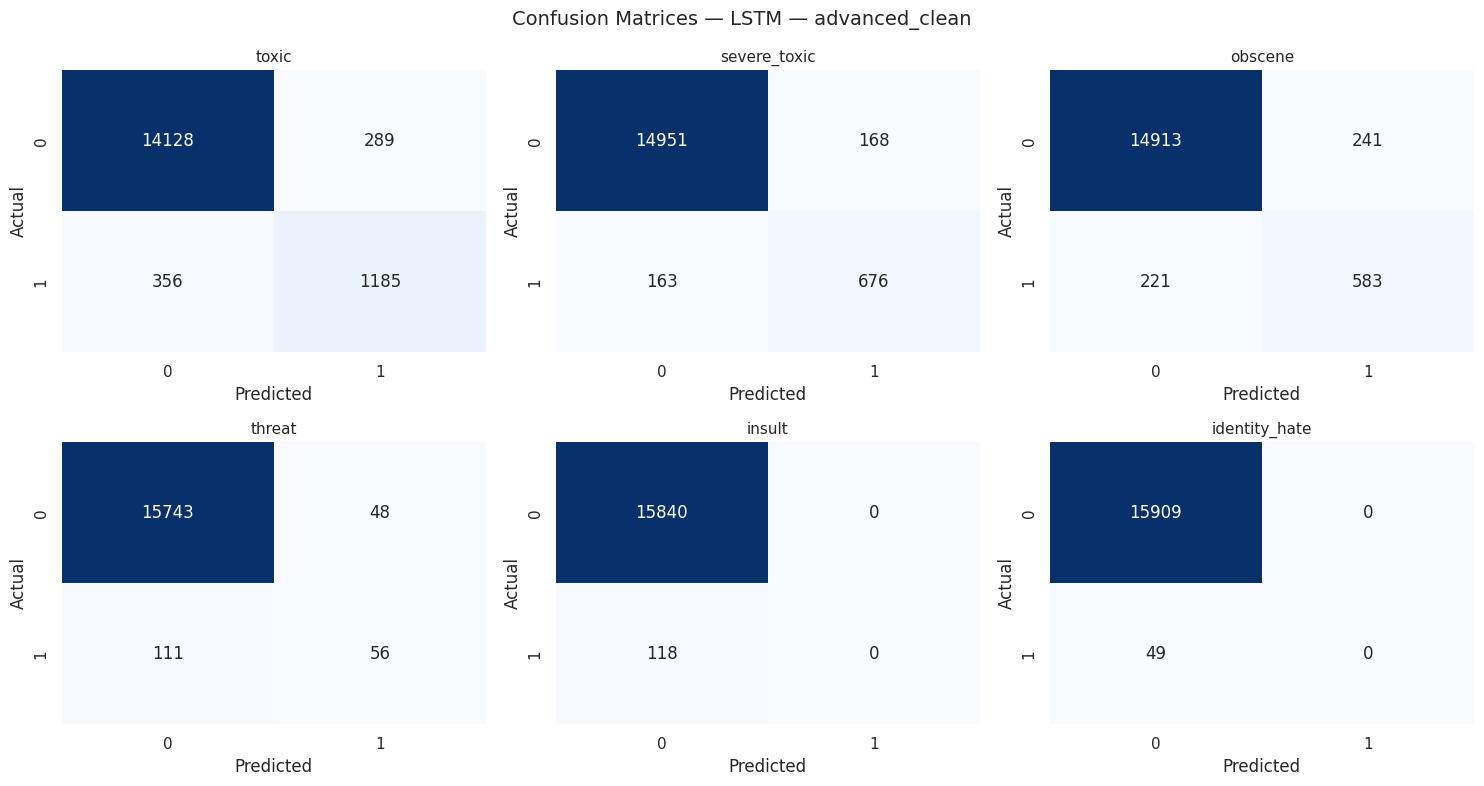

In [140]:
plot_confusion('LSTM — advanced_clean', y_test.values, y_pred_lstm,label_cols)

## Raw DATA

In [ ]:
lstm_tok_raw = Tokenizer(num_words=Vocab_size, oov_token='<OOV>')
lstm_tok_raw.fit_on_texts(X_train['raw'])

def to_padded_raw(texts):
    seqs = lstm_tok_raw.texts_to_sequences(texts)
    return pad_sequences(seqs, maxlen= max_len ,padding='post', truncating='post')

X_train_lstm_raw = to_padded_raw(X_train['raw'])
X_val_lstm_raw   = to_padded_raw(X_val['raw'])
X_test_lstm_raw  = to_padded_raw(X_test['raw'])

lstm_raw_model = build_bilstm(Vocab_size, max_len, NUM_LABELS)

t0 = time.time()
lstm_raw_model.fit(
    X_train_lstm_raw, y_train.values,
    validation_data=(X_val_lstm_raw, y_val.values),
    epochs=10, batch_size=256,
    callbacks=callbacks, verbose=1
)
lstm_model.save("lstm_raw_model.h5")

Epoch 1/10
499/499 ━━━━━━━━━━━━━━━━━━━━ 14s 23ms/step - accuracy: 0.8200 - loss: 0.0990 - val_accuracy: 0.9927 - val_loss: 0.0516 - learning_rate: 0.0010
Epoch 2/10
497/499 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9629 - loss: 0.0512
Epoch 2: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
499/499 ━━━━━━━━━━━━━━━━━━━━ 11s 22ms/step - accuracy: 0.9582 - loss: 0.0497 - val_accuracy: 0.9927 - val_loss: 0.0502 - learning_rate: 0.0010
Epoch 3/10
499/499 ━━━━━━━━━━━━━━━━━━━━ 11s 22ms/step - accuracy: 0.9411 - loss: 0.0450 - val_accuracy: 0.9927 - val_loss: 0.0507 - learning_rate: 5.0000e-04


In [ ]:
loaded_lstm = load_model("lstm_raw_model.h5")

In [ ]:
lstm_raw_train_time = time.time() - t0

t0 = time.time()
y_pred_lstm_raw = (lstm_raw_model.predict(X_test_lstm_raw) > 0.5).astype(int)
lstm_raw_infer = time.time() - t0

499/499 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step


In [ ]:
evaluate('LSTM — Raw', y_test.values, y_pred_lstm_raw, lstm_raw_train_time, lstm_raw_infer)


===== LSTM — Raw =====
  accuracy : 0.9179
  precision: 0.4776
  recall   : 0.3840
  f1 Macro : 0.4024
  train time: 36.6s


{'accuracy': 0.9179,
 'precision': 0.4776,
 'recall': 0.384,
 'f1 (macro)': 0.4024,
 'train time (s)': 36.6,
 'infer time (s)': 2.9}

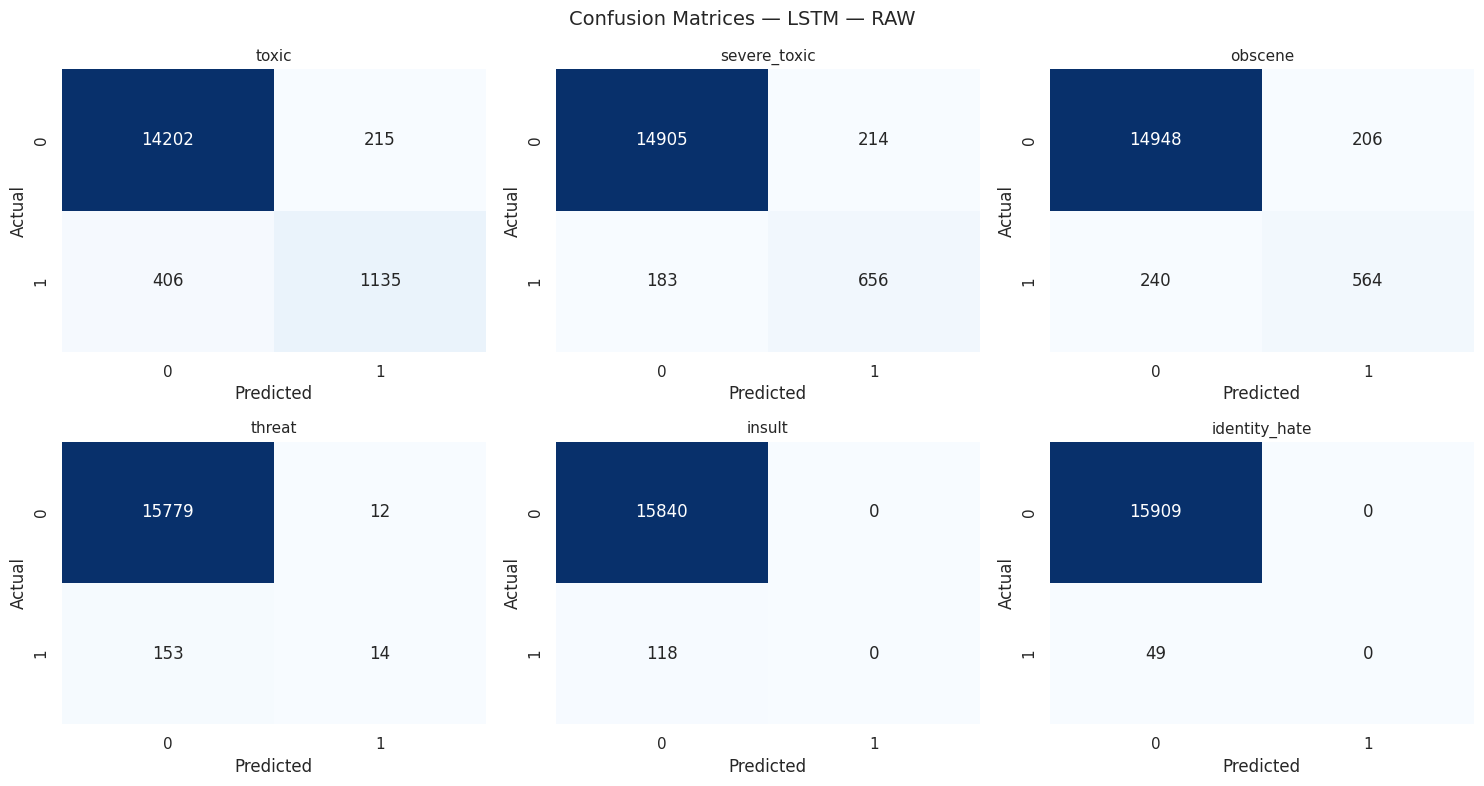

In [ ]:
plot_confusion('LSTM — RAW', y_test.values, y_pred_lstm_raw,label_cols)

Plot training curves

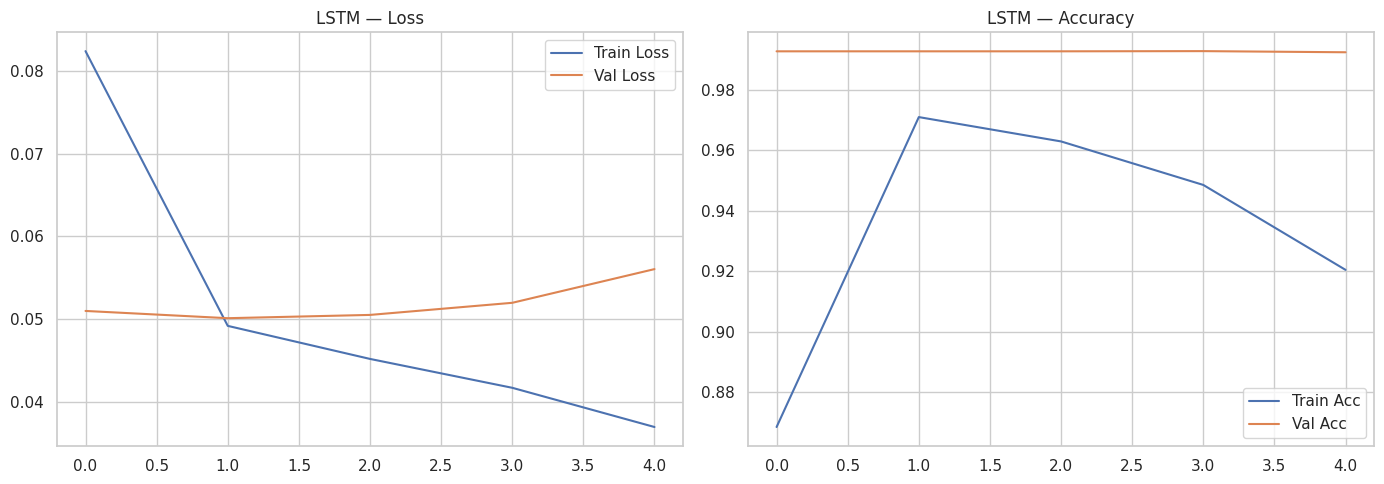

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history.history['loss'],     label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('LSTM — Loss'); axes[0].legend()

axes[1].plot(history.history['accuracy'],     label='Train Acc')
axes[1].plot(history.history['val_accuracy'], label='Val Acc')
axes[1].set_title('LSTM — Accuracy'); axes[1].legend()

plt.tight_layout()
plt.savefig('lstm_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# 11. Transformer Model

##  BERT Fine-tuning

11.1 dataset class

In [122]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

# Dataset
class ToxicDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts     = list(texts)
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            truncation=True,
            padding='max_length',
            return_tensors='pt'
        )
        return {
            'input_ids'     : enc['input_ids'].squeeze(0),
            'attention_mask': enc['attention_mask'].squeeze(0),
            'labels'        : torch.tensor(self.labels[idx], dtype=torch.float)
        }

Device: cuda


In [123]:
# Hyperparameters
BERT_BATCH = 32
BERT_EPOCHS = 1
BERT_MAX_LEN = 48

# Create datasets
train_ds = ToxicDataset(X_train['raw'].tolist(), y_train.values, Bert_tokenizer, BERT_MAX_LEN)
val_ds   = ToxicDataset(X_val['raw'].tolist(), y_val.values, Bert_tokenizer, BERT_MAX_LEN)
test_ds  = ToxicDataset(X_test['raw'].tolist(), y_test.values, Bert_tokenizer, BERT_MAX_LEN)

# DataLoaders
train_loader = DataLoader(train_ds, batch_size=BERT_BATCH, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=BERT_BATCH)
test_loader  = DataLoader(test_ds, batch_size=BERT_BATCH)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))


Train batches: 3990
Val batches: 499


11.2 Load the model

In [124]:
bert_model = BertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=NUM_LABELS,
    problem_type='multi_label_classification'
).to(DEVICE)


loading configuration file config.json from cache at /root/.cache/huggingface/hub/models--distilbert-base-uncased/snapshots/12040accade4e8a0f71eabdb258fecc2e7e948be/config.json
You are using a model of type distilbert to instantiate a model of type bert. This is not supported for all configurations of models and can yield errors.
Model config BertConfig {
  "activation": "gelu",
  "add_cross_attention": false,
  "architectures": [
    "DistilBertForMaskedLM"
  ],
  "attention_dropout": 0.1,
  "attention_probs_dropout_prob": 0.1,
  "bos_token_id": null,
  "classifier_dropout": null,
  "dim": 768,
  "dropout": 0.1,
  "eos_token_id": null,
  "hidden_act": "gelu",
  "hidden_dim": 3072,
  "hidden_dropout_prob": 0.1,
  "hidden_size": 768,
  "id2label": {
    "0": "LABEL_0",
    "1": "LABEL_1",
    "2": "LABEL_2",
    "3": "LABEL_3",
    "4": "LABEL_4",
    "5": "LABEL_5"
  },
  "initializer_range": 0.02,
  "intermediate_size": 3072,
  "is_decoder": false,
  "label2id": {
    "LABEL_0": 0,
  

Loading weights: 0it [00:00, ?it/s]

BertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                                                                      | Status     | 
-------------------------------------------------------------------------+------------+-
distilbert.transformer.layer.{0, 1, 2, 3, 4, 5}.attention.out_lin.bias   | UNEXPECTED | 
distilbert.transformer.layer.{0, 1, 2, 3, 4, 5}.ffn.lin1.bias            | UNEXPECTED | 
distilbert.transformer.layer.{0, 1, 2, 3, 4, 5}.output_layer_norm.bias   | UNEXPECTED | 
distilbert.transformer.layer.{0, 1, 2, 3, 4, 5}.ffn.lin2.bias            | UNEXPECTED | 
distilbert.transformer.layer.{0, 1, 2, 3, 4, 5}.attention.out_lin.weight | UNEXPECTED | 
distilbert.transformer.layer.{0, 1, 2, 3, 4, 5}.attention.q_lin.bias     | UNEXPECTED | 
distilbert.transformer.layer.{0, 1, 2, 3, 4, 5}.attention.q_lin.weight   | UNEXPECTED | 
distilbert.embeddings.word_embeddings.weight                             | UNEXPECTED | 
distilbert.transformer.layer.{0, 1, 2,

In [125]:
optimizer = AdamW(bert_model.parameters(), lr=2e-5, weight_decay=0.01)

total_steps = len(train_loader) * BERT_EPOCHS

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps
)

criterion = torch.nn.BCEWithLogitsLoss()

print("BERT model ready.")

BERT model ready.


11.3 Training

In [149]:
def run_epoch(model, loader, train=True):
    model.train() if train else model.eval()

    total_loss = 0
    all_preds, all_labels = [], []

    with torch.set_grad_enabled(train):

        for batch in loader:

            input_ids = batch['input_ids'].to(DEVICE)
            attention_mask = batch['attention_mask'].to(DEVICE)
            labels = batch['labels'].to(DEVICE).float()

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

            logits = outputs.logits

            loss = criterion(logits, labels)

            if train:
                optimizer.zero_grad()
                loss.backward()

                torch.nn.utils.clip_grad_norm_(
                    model.parameters(), 1.0
                )

                optimizer.step()
                scheduler.step()

            total_loss += loss.item()

            probs = torch.sigmoid(logits)

            preds = (probs > 0.5).cpu().numpy()

            all_preds.append(preds)
            all_labels.append(labels.cpu().numpy())

    return (
        total_loss / len(loader),
        np.vstack(all_preds),
        np.vstack(all_labels)
    )

11.3 training loop

In [150]:
best_val_loss = float('inf')

bert_train_losses = []
bert_val_losses = []

for epoch in range(BERT_EPOCHS):

    start = time.time()

    train_loss, _, _ = run_epoch(
        bert_model,
        train_loader,
        train=True
    )

    val_loss, val_preds, val_labels = run_epoch(
        bert_model,
        val_loader,
        train=False
    )

    bert_train_losses.append(train_loss)
    bert_val_losses.append(val_loss)

    val_f1 = f1_score(
        val_labels,
        val_preds,
        average='macro',
        zero_division=0
    )

    elapsed = time.time() - start

    print(
        f'Epoch {epoch+1}/{BERT_EPOCHS} | '
        f'Train Loss: {train_loss:.4f} | '
        f'Val Loss: {val_loss:.4f} | '
        f'Val F1: {val_f1:.4f} | '
        f'Time: {elapsed:.0f}s'
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(
            bert_model.state_dict(),
            'best_bert.pt'
        )

Epoch 1/1 | Train Loss: 0.0775 | Val Loss: 0.0558 | Val F1: 0.4187 | Time: 1199s


11.4 evaluation

In [151]:
evaluate(
    'BERT — Raw',
    y_true_bert,
    y_pred_bert,
    elapsed,
    bert_infer_t
)


===== BERT — Raw =====
  accuracy : 0.9157
  precision: 0.4815
  recall   : 0.4338
  f1 Macro : 0.4536
  train time: 1199.4s


{'accuracy': 0.9157,
 'precision': 0.4815,
 'recall': 0.4338,
 'f1 (macro)': 0.4536,
 'train time (s)': 1199.4,
 'infer time (s)': 64.3}

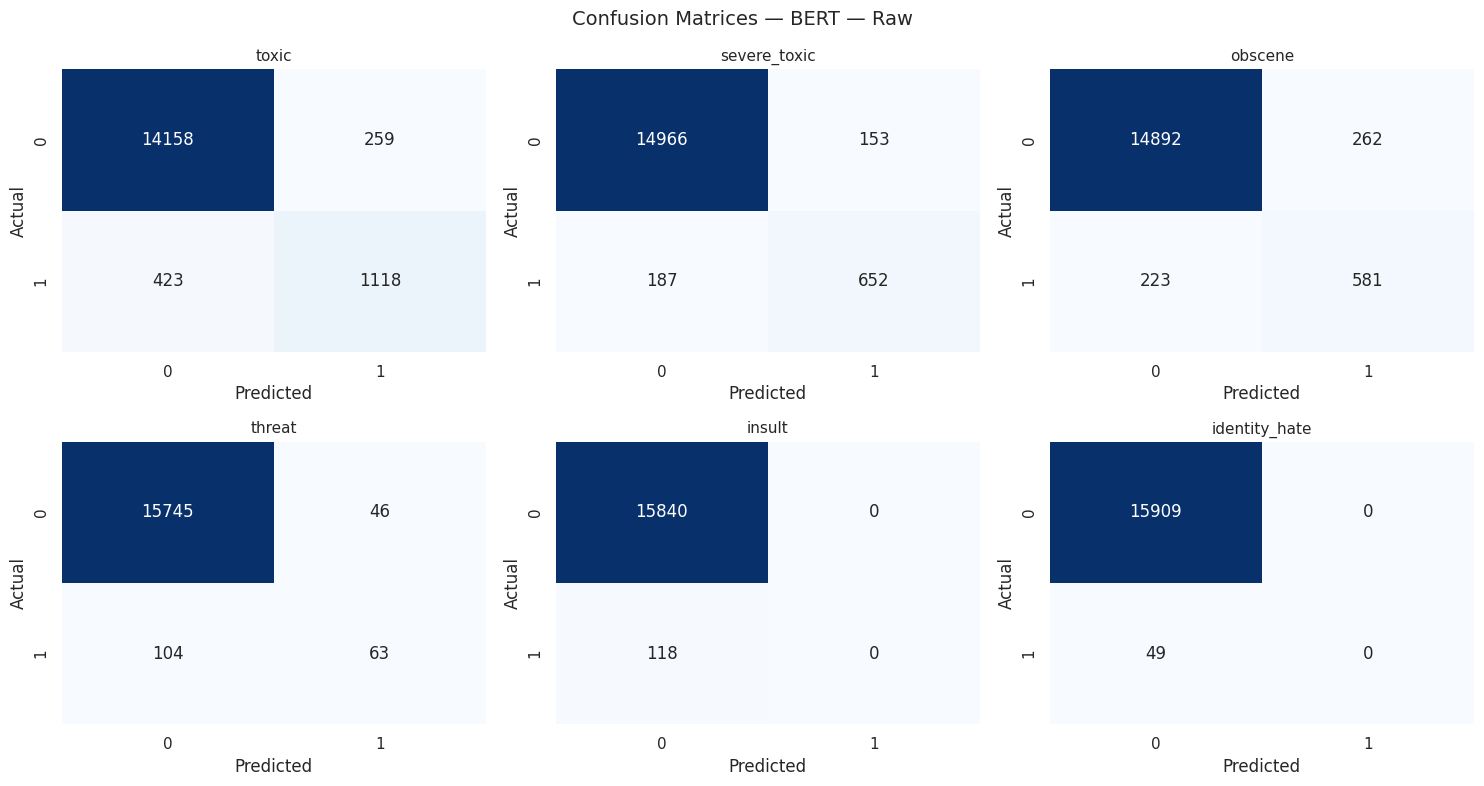

In [182]:
plot_confusion('BERT — Raw', y_true_bert, y_pred_bert)

# 12. Comparative Analysis


## 12.1 performance comparison

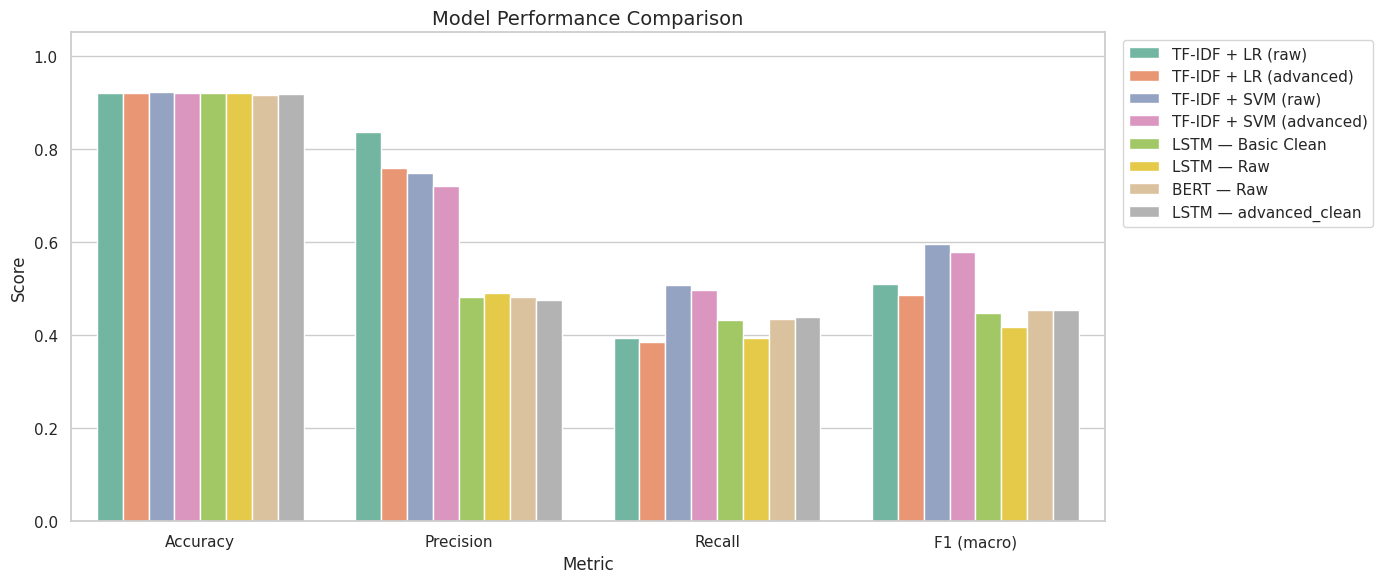

In [146]:
metric_cols = ['accuracy', 'precision', 'recall', 'f1 (macro)']

results_df = pd.DataFrame.from_dict(results, orient='index').reset_index().rename(columns={'index': 'Model'})
plot_df = results_df[['Model'] + metric_cols].copy()
plot_df[metric_cols] = plot_df[metric_cols].astype(float)

plot_melted = plot_df.melt(id_vars='Model', value_vars=metric_cols,
                           var_name='Metric', value_name='Score')

display_name_map = {
    'accuracy': 'Accuracy',
    'precision': 'Precision',
    'recall': 'Recall',
    'f1 (macro)': 'F1 (macro)'
}
plot_melted['Metric'] = plot_melted['Metric'].map(display_name_map)


plt.figure(figsize=(14, 6))
sns.barplot(data=plot_melted, x='Metric', y='Score', hue='Model',
            palette='Set2')
plt.title('Model Performance Comparison', fontsize=14)
plt.ylim(0, 1.05)
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 12.2 preprocessing impact

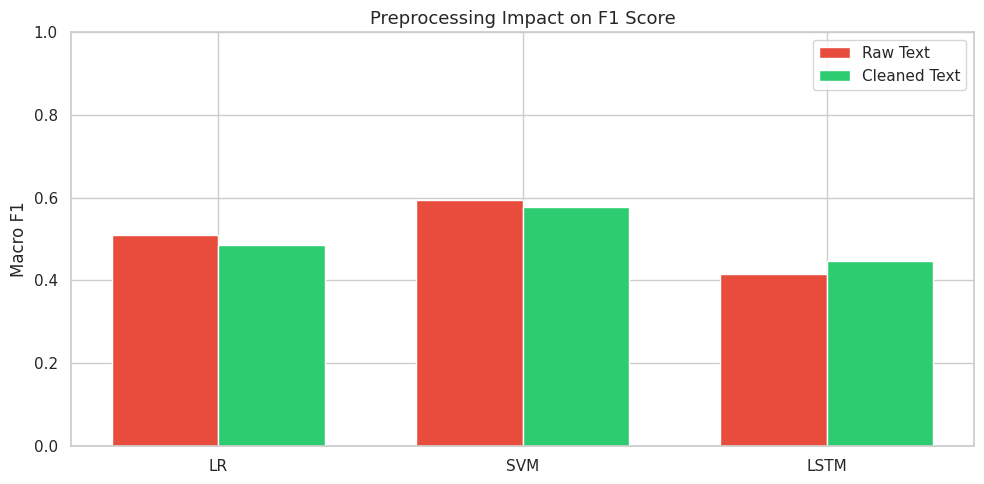

  Architecture  F1 Raw  F1 Cleaned
0           LR  0.5099      0.4852
1          SVM  0.5944      0.5780
2         LSTM  0.4165      0.4463


In [181]:
raw_models = [m for m in results if 'raw' in m.lower()]

clean_models = [
    m for m in results
    if 'clean' in m.lower() or 'advanced' in m.lower()
]

preprocess_rows = []
for arch in ['LR','SVM','LSTM']:
    raw_key   = next((m for m in raw_models   if arch.lower() in m.lower()), None)
    clean_key = next((m for m in clean_models if arch.lower() in m.lower()), None)
    if raw_key and clean_key:
        preprocess_rows.append({
            'Architecture': arch,
            'F1 Raw'      : results[raw_key]['f1 (macro)'],
            'F1 Cleaned'  : results[clean_key]['f1 (macro)']
        })

preproc_df = pd.DataFrame(preprocess_rows)

x = np.arange(len(preproc_df))
w = 0.35
fig, ax = plt.subplots(figsize=(10,5))
ax.bar(x - w/2, preproc_df['F1 Raw'],     w, label='Raw Text',     color='#e74c3c')
ax.bar(x + w/2, preproc_df['F1 Cleaned'], w, label='Cleaned Text', color='#2ecc71')
ax.set_xticks(x); ax.set_xticklabels(preproc_df['Architecture'])
ax.set_title('Preprocessing Impact on F1 Score', fontsize=13)
ax.set_ylabel('Macro F1')
ax.set_ylim(0, 1.0)
ax.legend()
plt.tight_layout()
plt.savefig('preprocessing_impact.png', dpi=150, bbox_inches='tight')
plt.show()

print(preproc_df)

## 12.3 training time

In [ ]:
time_df = results_df[['Model', 'train time (s)']].copy()
time_df = time_df[time_df['train time (s)'] != '-']
time_df['train time (s)'] = time_df['train time (s)'].astype(float)

plt.figure(figsize=(12, 5))
sns.barplot(data=time_df, x='Model', y='train time (s)', palette='Blues_d')
plt.title('Training Time Comparison (seconds)', fontsize=13)
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig('training_time.png', dpi=150, bbox_inches='tight')
plt.show()

## 12.4 error analysis

In [185]:
test_texts = X_test['raw'].values

wrong_mask = (y_true_bert != y_pred_bert).any(axis=1)
wrong_idx  = np.where(wrong_mask)[0]

print(f'Misclassified samples (BERT): {wrong_mask.sum()} / {len(y_true_bert)}')

error_df = pd.DataFrame({
    'text'       : [test_texts[i][:200] for i in wrong_idx[:20]],
    'true_labels': [dict(zip(label_cols, y_true_bert[i])) for i in wrong_idx[:20]],
    'pred_labels': [dict(zip(label_cols, y_pred_bert[i])) for i in wrong_idx[:20]]
})

pd.set_option('display.max_colwidth', 120)
error_df.head(10)

Misclassified samples (BERT): 1345 / 15958


,text,true_labels,pred_labels
0,"""I think all of you americans you have a real attitude and mental problem !\nFirst you live in a World full of consp...","{'toxic': 1.0, 'severe_toxic': 1.0, 'obscene': 1.0, 'threat': 0.0, 'insult': 0.0, 'identity_hate': 0.0}","{'toxic': False, 'severe_toxic': False, 'obscene': False, 'threat': False, 'insult': False, 'identity_hate': False}"
1,"""\n\n Swedish joke #1 \n\nSince self-righteous Mr.choppers knows nothing about the USDM D15B8 which he relentlessly ...","{'toxic': 1.0, 'severe_toxic': 0.0, 'obscene': 0.0, 'threat': 0.0, 'insult': 0.0, 'identity_hate': 0.0}","{'toxic': False, 'severe_toxic': False, 'obscene': False, 'threat': False, 'insult': False, 'identity_hate': False}"
2,And this meat puppet would be whom? Tim Foxworth,"{'toxic': 1.0, 'severe_toxic': 0.0, 'obscene': 0.0, 'threat': 0.0, 'insult': 0.0, 'identity_hate': 0.0}","{'toxic': False, 'severe_toxic': False, 'obscene': False, 'threat': False, 'insult': False, 'identity_hate': False}"
3,Holy Jesus crap \n\nYou just commited the worst sin possible & theres no redemtion so once you die you be going to h...,"{'toxic': 1.0, 'severe_toxic': 0.0, 'obscene': 0.0, 'threat': 0.0, 'insult': 0.0, 'identity_hate': 0.0}","{'toxic': True, 'severe_toxic': False, 'obscene': True, 'threat': False, 'insult': False, 'identity_hate': False}"
4,"It presumes that the dumbfucks who troll about the ending have any good reason to do so, so it is biased.","{'toxic': 1.0, 'severe_toxic': 1.0, 'obscene': 1.0, 'threat': 0.0, 'insult': 0.0, 'identity_hate': 0.0}","{'toxic': True, 'severe_toxic': False, 'obscene': False, 'threat': False, 'insult': False, 'identity_hate': False}"
5,2011 French Open \n\nDon't leave silly little messages on my talk page saying I haven't explained myself and revert ...,"{'toxic': 1.0, 'severe_toxic': 0.0, 'obscene': 0.0, 'threat': 0.0, 'insult': 0.0, 'identity_hate': 0.0}","{'toxic': False, 'severe_toxic': False, 'obscene': False, 'threat': False, 'insult': False, 'identity_hate': False}"
6,"""\n\n Oh and as far as """"not in line at all with how things are done"""", that's pure horse shit and you know it. Disa...","{'toxic': 1.0, 'severe_toxic': 1.0, 'obscene': 1.0, 'threat': 0.0, 'insult': 0.0, 'identity_hate': 0.0}","{'toxic': True, 'severe_toxic': False, 'obscene': False, 'threat': False, 'insult': False, 'identity_hate': False}"
7,dude wtf \n\nI was cleaning off some junk that slipped in when I copypasted my stuff so I could add a comment when s...,"{'toxic': 0.0, 'severe_toxic': 0.0, 'obscene': 0.0, 'threat': 0.0, 'insult': 0.0, 'identity_hate': 0.0}","{'toxic': True, 'severe_toxic': False, 'obscene': False, 'threat': False, 'insult': False, 'identity_hate': False}"
8,"By the way, are there any Azeris looking like this guy. Having lived among the Jews for a long time I can declare th...","{'toxic': 0.0, 'severe_toxic': 0.0, 'obscene': 0.0, 'threat': 0.0, 'insult': 0.0, 'identity_hate': 0.0}","{'toxic': True, 'severe_toxic': False, 'obscene': False, 'threat': False, 'insult': False, 'identity_hate': False}"
9,"Lying, scheming, vindictive Weasel \n\nBurn in hell.","{'toxic': 1.0, 'severe_toxic': 0.0, 'obscene': 1.0, 'threat': 0.0, 'insult': 0.0, 'identity_hate': 0.0}","{'toxic': True, 'severe_toxic': False, 'obscene': False, 'threat': False, 'insult': False, 'identity_hate': False}"


#14. Final Discussion


In [180]:
print('\n' + '='*70)
print('FINAL RESULTS SUMMARY')
print('='*70)

print(results_df.to_string(index=False))

print('='*70)

# Pick highest F1
best_fast = results_df.loc[
    results_df['infer time (s)'].idxmin()
]


print(f'\n🏆 Best model : {best_model["Model"]}')
print(f"\n⚡ Fastest model: {best_fast['Model']}")
print(f"🏆 Most accurate model: {best_model['Model']}")
print(f' F1 (macro) : {best_model["f1 (macro)"]:.4f}')
print(f' Accuracy   : {best_model["accuracy"]:.4f}')


FINAL RESULTS SUMMARY
                  Model  accuracy  precision  recall  f1 (macro)  train time (s)  infer time (s)
      TF-IDF + LR (raw)    0.9204     0.8366  0.3936      0.5099            18.5             0.0
 TF-IDF + LR (advanced)    0.9189     0.7585  0.3845      0.4852            10.8             0.0
     TF-IDF + SVM (raw)    0.9209     0.7476  0.5065      0.5944            11.4             0.0
TF-IDF + SVM (advanced)    0.9187     0.7193  0.4957      0.5780             6.3             0.0
     LSTM — Basic Clean    0.9187     0.4813  0.4325      0.4463            90.9             5.2
             LSTM — Raw    0.9189     0.4895  0.3934      0.4165            36.9             2.9
             BERT — Raw    0.9157     0.4815  0.4338      0.4536          1214.5            64.3
  LSTM — advanced_clean    0.9170     0.4751  0.4392      0.4531           130.7             5.2

🏆 Best model : TF-IDF + SVM (raw)

⚡ Fastest model: TF-IDF + LR (raw)
🏆 Most accurate model: TF-IDF + S

Raw SVM

In [129]:
sample_comments = [
    "I love your videos",
    "You are a stupid idiot",
    "Have a nice day",
    "Shut up moron",
    "Amazing work"
]

sample_tfidf_raw = tfidf_raw.transform(sample_comments)

pred_raw = svm_raw.predict(sample_tfidf_raw)

for text, pred in zip(sample_comments, pred_raw):

    print("\nComment:", text)

    toxic_found = False

    for label, value in zip(label_cols, pred):

        if value == 1:
            toxic_found = True
            print(f"{label}: Toxic")

    if not toxic_found:
        print("Prediction: Non-toxic")


Comment: I love your videos
Prediction: Non-toxic

Comment: You are a stupid idiot
toxic: Toxic
severe_toxic: Toxic
obscene: Toxic

Comment: Have a nice day
Prediction: Non-toxic

Comment: Shut up moron
toxic: Toxic
severe_toxic: Toxic
obscene: Toxic

Comment: Amazing work
Prediction: Non-toxic


Advanced SVM

In [128]:
sample_comments = [
    "I love your videos",
    "You are a stupid id#ot",
    "Have a nice day",
    "Shut up moron",
    "Amazing work"
]

sample_clean = [
    advanced_preprocess(t)
    for t in sample_comments
]

sample_tfidf_clean = tfidf_clean.transform(sample_clean)

pred_clean = svm_clean.predict(sample_tfidf_clean)

for text, pred in zip(sample_comments, sample_pred):

    print("\nComment:", text)

    toxic_found = False

    for label, value in zip(label_cols, pred):

        if value == 1:
            toxic_found = True
            print(f"{label}: Toxic")

    if not toxic_found:
        print("Prediction: Non-toxic")


Comment: I love your videos
Prediction: Non-toxic

Comment: You are a stupid id#ot
Prediction: Non-toxic

Comment: Have a nice day
Prediction: Non-toxic

Comment: Shut up moron
toxic: Toxic
severe_toxic: Toxic
obscene: Toxic

Comment: Amazing work
Prediction: Non-toxic


In [144]:
sample_comments = [
    "I love your videos",
    "You are a stupid idiot",
    "Have a nice day",
    "Shut up moron",
    "Amazing work"
]

sample_seq_raw = lstm_tok_raw.texts_to_sequences(
    sample_comments
)

sample_pad_raw = pad_sequences(
    sample_seq_raw,
    maxlen=max_len,
    padding='post',
    truncating='post'
)


pred_probs_raw = lstm_raw_model.predict(sample_pad_raw)

pred_raw = (pred_probs_raw > 0.5).astype(int)

# display results
for text, pred in zip(sample_comments, pred_raw):

    print("\nComment:", text)

    toxic_found = False

    for label, value in zip(label_cols, pred):

        if value == 1:
            toxic_found = True
            print(f"{label}: Toxic")

    if not toxic_found:
        print("Prediction: Non-toxic")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step

Comment: I love your videos
Prediction: Non-toxic

Comment: You are a stupid idiot
toxic: Toxic
severe_toxic: Toxic
obscene: Toxic

Comment: Have a nice day
Prediction: Non-toxic

Comment: Shut up moron
toxic: Toxic
severe_toxic: Toxic
obscene: Toxic

Comment: Amazing work
Prediction: Non-toxic


In [145]:
sample_comments = [
    "I love your videos",
    "You are a stupid idiot",
    "Have a nice day",
    "Shut up moron",
    "Amazing work"
]

sample_clean = [
    advanced_preprocess(t)
    for t in sample_comments
]

sample_seq_clean = lstm_tok.texts_to_sequences(sample_clean)


sample_pad_clean = pad_sequences(
    sample_seq_clean,
    maxlen=max_len,
    padding='post',
    truncating='post'
)

pred_probs_clean = lstm_model.predict(sample_pad_clean)

pred_clean = (pred_probs_clean > 0.5).astype(int)

for text, pred in zip(sample_comments, pred_clean):

    print("\nComment:", text)

    toxic_found = False

    for label, value in zip(label_cols, pred):
        if value == 1:
            toxic_found = True
            print(f"{label}: Toxic")

    if not toxic_found:
        print("Prediction: Non-toxic")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step

Comment: I love your videos
Prediction: Non-toxic

Comment: You are a stupid idiot
toxic: Toxic
severe_toxic: Toxic
obscene: Toxic

Comment: Have a nice day
Prediction: Non-toxic

Comment: Shut up moron
toxic: Toxic
severe_toxic: Toxic
obscene: Toxic

Comment: Amazing work
Prediction: Non-toxic


Bert

In [153]:
# Load best saved weights (optional if model already in memory)
bert_model.load_state_dict(torch.load("best_bert.pt"))
bert_model.to(DEVICE)
bert_model.eval()


test_comments = [
    "I really love your work, keep it up!",
    "You are a stupid idiot",
    "Shut up moron",
    "bruh this is so dumb",
    "Wow great job ruining everything 👍",
    "I hate this so much 😡",
    "You are amazing 😂😂",
    "Not perfect, but still okay work",
    "The weather is nice today",
    "This is the worst explanation ever",
    "Kill yourself",
    "You are useless"
]


# Tokenize using SAME tokenizer as training
encodings = Bert_tokenizer(
    test_comments,
    truncation=True,
    padding='max_length',
    max_length=BERT_MAX_LEN,
    return_tensors='pt'
)

input_ids = encodings['input_ids'].to(DEVICE)
attention_mask = encodings['attention_mask'].to(DEVICE)


# Predict
with torch.no_grad():

    outputs = bert_model(
        input_ids=input_ids,
        attention_mask=attention_mask
    )

    probs = torch.sigmoid(outputs.logits)

    preds = (probs > 0.5).cpu().numpy()


# Show results + probabilities
for text, pred, prob in zip(test_comments, preds, probs.cpu().numpy()):

    print("\n" + "="*50)
    print("Comment:", text)

    toxic_found = False

    for label, p, value in zip(label_cols, prob, pred):

        if value == 1:
            toxic_found = True
            print(f"{label}: Toxic ({p:.3f})")

    if not toxic_found:
        print("Prediction: Non-toxic")

    print("Probabilities:")
    for label, p in zip(label_cols, prob):
        print(f" {label}: {p:.3f}")


Comment: I really love your work, keep it up!
Prediction: Non-toxic
Probabilities:
 toxic: 0.037
 severe_toxic: 0.004
 obscene: 0.006
 threat: 0.001
 insult: 0.001
 identity_hate: 0.001

Comment: You are a stupid idiot
toxic: Toxic (0.992)
severe_toxic: Toxic (0.971)
obscene: Toxic (0.870)
Probabilities:
 toxic: 0.992
 severe_toxic: 0.971
 obscene: 0.870
 threat: 0.366
 insult: 0.201
 identity_hate: 0.056

Comment: Shut up moron
toxic: Toxic (0.984)
severe_toxic: Toxic (0.914)
obscene: Toxic (0.764)
Probabilities:
 toxic: 0.984
 severe_toxic: 0.914
 obscene: 0.764
 threat: 0.154
 insult: 0.145
 identity_hate: 0.034

Comment: bruh this is so dumb
toxic: Toxic (0.897)
severe_toxic: Toxic (0.648)
Probabilities:
 toxic: 0.897
 severe_toxic: 0.648
 obscene: 0.477
 threat: 0.022
 insult: 0.065
 identity_hate: 0.014

Comment: Wow great job ruining everything 👍
Prediction: Non-toxic
Probabilities:
 toxic: 0.009
 severe_toxic: 0.002
 obscene: 0.002
 threat: 0.001
 insult: 0.001
 identity_hate:

In [175]:
def compare_models():

    text = input("Enter comment: ")

    rows = []

    # ---------------- LR ----------------
    start = time.time()

    x = tfidf_clean.transform([advanced_preprocess(text)])
    pred = lr_clean.predict(x)[0]

    rows.append([
        "LR",
        ", ".join([l for l,v in zip(label_cols,pred) if v==1]) or "Non-toxic",
        results['TF-IDF + LR (advanced)']['accuracy'],
        results['TF-IDF + LR (advanced)']['f1 (macro)'],
        round(time.time()-start,3)
    ])


    # ---------------- SVM ----------------
    start = time.time()

    pred = svm_clean.predict(x)[0]

    rows.append([
        "SVM",
        ", ".join([l for l,v in zip(label_cols,pred) if v==1]) or "Non-toxic",
        results['TF-IDF + SVM (advanced)']['accuracy'],
        results['TF-IDF + SVM (advanced)']['f1 (macro)'],
        round(time.time()-start,3)
    ])


    # ---------------- BiLSTM ----------------
    start = time.time()

    seq = lstm_tok.texts_to_sequences(
        [advanced_preprocess(text)]
    )

    pad = pad_sequences(seq,maxlen=max_len)

    pred = (
        lstm_model.predict(
            pad,
            verbose=0
        ) > 0.5
    ).astype(int)[0]

    rows.append([
        "BiLSTM",
        ", ".join([l for l,v in zip(label_cols,pred) if v==1]) or "Non-toxic",
        results['LSTM — advanced_clean']['accuracy'],
        results['LSTM — advanced_clean']['f1 (macro)'],
        round(time.time()-start,3)
    ])


    # ---------------- BERT ----------------
    start = time.time()

    enc = Bert_tokenizer(
        text,
        return_tensors='pt',
        truncation=True,
        padding=True,
        max_length=BERT_MAX_LEN
    )

    with torch.no_grad():

        out = bert_model(
            input_ids=enc['input_ids'].to(DEVICE),
            attention_mask=enc['attention_mask'].to(DEVICE)
        )

    pred = (
        torch.sigmoid(out.logits)>0.5
    ).cpu().numpy()[0]

    rows.append([
        "BERT",
        ", ".join([l for l,v in zip(label_cols,pred) if v==1]) or "Non-toxic",
        results['BERT — Raw']['accuracy'],
        results['BERT — Raw']['f1 (macro)'],
        round(time.time()-start,3)
    ])



    df = pd.DataFrame(
        rows,
        columns=[
            "Model",
            "Prediction",
            "Accuracy",
            "F1",
            "Inference Time(s)"
        ]
    )

    print("\nInput:")
    print(text)
    print()

    display(df)

    # ---------- Best model ----------
    best = df.loc[df["F1"].idxmax()]

    print(
        f"\n🏆 Best Model Overall: "
        f"{best['Model']} "
        f"(F1={best['F1']}, "
        f"Accuracy={best['Accuracy']})"
    )

In [177]:
compare_models()

Enter comment: I hate this so much 😡

Input:
I hate this so much 😡



,Model,Prediction,Accuracy,F1,Inference Time(s)
0,LR,Non-toxic,0.9189,0.4852,0.004
1,SVM,toxic,0.9187,0.5780,0.008
2,BiLSTM,Non-toxic,0.9170,0.4531,0.187
3,BERT,Non-toxic,0.9157,0.4536,0.049



🏆 Best Model Overall: SVM (F1=0.578, Accuracy=0.9187)


# UI